# QQE — a quantitative teardown 🔬
### Causal smoothed-RSI trailing-band crosses on 5 indices · band-cross forward returns · one-sample HAC *t* · a **pooled** drift-matched random-entry baseline · a phase-scramble geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Band-cross_forecasts%3F: Busted](https://img.shields.io/badge/Band--cross_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **signal** from the **drift**: an upward-trending index makes *any* long-only entry look good, so the only meaningful test is cross-vs-random, plus a placebo that destroys the indicator's timing while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. QQE is causal (RSI len 14, smoothing 5, factor 4.236); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from qqe import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real QQE cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 697, 'rsi_len': 14, 'sf': 5, 'qf': 4.236, 'fp_spy': '4cb5244f3990', 'h5': (5, 696, 31.5, 59, 3.72, 28.8, 2.8, 29.5, 0.28, 0.777), 'h10': (10, 696, 60.3, 62, 5.39, 57.0, 3.3, 58.3, 0.25, 0.802), 'h20': (20, 695, 100.7, 64, 7.01, 110.6, -9.9, 98.7, -0.5, 0.619), 'h60': (60, 690, 310.2, 70, 9.05, 304.1, 6.0, 308.2, 0.19, 0.846), 'per': [('SPY', 139, 103.6, 3.48, 104.8, -1.2), ('QQQ', 142, 104.5, 2.96, 150.8, -46.3), ('IWM', 140, 118.9, 2.93, 101.1, 17.8), ('DIA', 136, 84.0, 3.34, 92.0, -8.0), ('GLD', 140, 92.1, 2.37, 103.0, -10.9)], 'placebo': (103.6, 0.313, 500), 'syn': [(0.0, 107, -64.3, 46, -1.47), (0.6, 81, 703.3, 81, 9.73)]}


real QQE cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Band-cross vs a **pooled drift-matched random** baseline: Δ = +3/+3/-10/+6 bps and the cross-minus-random Welch *t* **never clears t = 2** (max +0.28 at 5d). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 7.01) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Band-cross forecasts?** | `BUSTED` | Scrambling the price timing (phase-scramble placebo) leaves the result intact: **p = 0.31** of nonsense-timing tapes match or beat the real one. The geometry isn't doing the work. |

> 💡 In plain words: the band-cross *looks* significant only because indices drift up. Strip the drift (race it vs a **pooled** random) or strip the timing (scramble the tape) and the edge evaporates. Classic beta-in-a-costume — with a baseline-estimation twist.

## 1 · The claim, steelmanned

Let $R_t$ be Wilder's RSI, $\overline{R}_t = \mathrm{EMA}_{sf}(R_t)$ the smoothed RSI, and $\delta_t = f\cdot\mathrm{ATR}_{rsi}(\overline{R})_t$ the band half-width ($f=4.236$). A dual trailing stop $T_t$ flips between $\overline{R}_t-\delta_t$ (below) and $\overline{R}_t+\delta_t$ (above). The QQE rule buys when $\overline{R}_t$ crosses **above** $T_t$.

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (QQE forecasts).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Cross returns exceed a **phase-scrambled** tape whose timing is destroyed.

We find **H₀ not rejected** (cross ≈ random), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.31). The steelman fails on every leg.

## 2 · So what? — the confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random.

**(b) Baseline estimation error.** A *single* random draw of a few hundred dates has a noisy mean — a lucky-low draw fabricates a fake edge. We therefore **pool the baseline over 40 seeds** (~28k entries), estimating the true drift. *This is the load-bearing design choice here*: the single-seed comparison makes QQE look like a winner; the pooled one reveals it as nothing.

**(c) Geometry as a free re-description.** QQE is a smoothed function of past price, so it 'fires in uptrends' tautologically. The **phase-scramble placebo** keeps the spectrum and return marginal but destroys the timing — if the real result survives, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **697 band-crosses** pooled.
- **QQE.** Causal: Wilder RSI (len 14) → EMA smoothing (5) → ATR-of-RSI × 4.236 dual-band trailing stop. Cross read on close of *t*.
- **Entry.** First bar RSI MA crosses above the stop; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — pooled random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — phase-scramble placebo** (timing destroyed, spectrum/marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** post-cross continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the band-cross's **one-sample** t against zero (the misleading number). Right: the same cross vs a **pooled drift-matched random** baseline (the honest number).

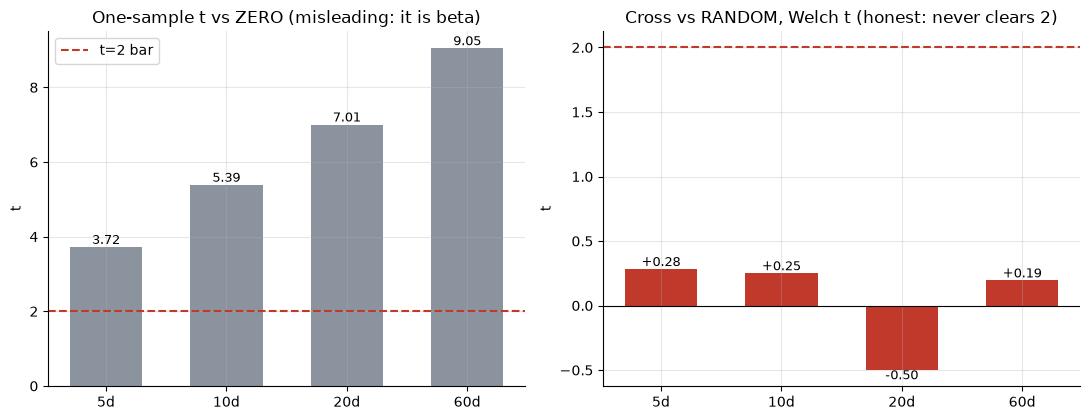

one-sample t: [3.72, 5.39, 7.01, 9.05]
welch vs random: [np.float64(0.28), np.float64(0.25), np.float64(-0.5), np.float64(0.19)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.qqe_cross_entries(c, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
            tt.append(st.forward_returns(c, e, h)); rr.append(st.random_baseline(c, max(len(e),50), h, n_seeds=40))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **7.01**, 60d **9.05**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: cross-minus-random is near zero (-0.50 at 20d) — never significant. QQE adds nothing over a coin flip.

### 4b · The lucky-seed trap — why pooling the baseline matters

Here's the subtle bit. If you compare the cross to a **single** random draw, the baseline is noisy — and one unlucky-low draw makes QQE look like a real winner. Below: the distribution of the cross-minus-random Δ across 200 single-seed baselines (grey), vs the pooled estimate (blue). The single-seed Δ swings wildly; the pooled one sits at ~0.

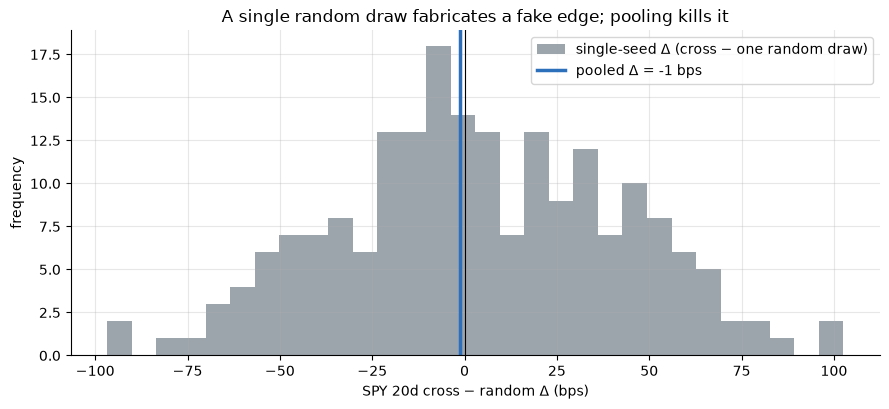

single-seed Δ: mean +4, sd 38 bps; pooled Δ -1 bps


In [3]:
if HAVE_REAL:
    c = load('SPY')['close']; h = 20
    e = st.qqe_cross_entries(c, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
    cross_mean = st.forward_returns(c, e, h).mean()*1e4
    deltas = []
    for s in range(200):
        re = st.random_entries(c, max(len(e),50), seed=s)
        deltas.append(cross_mean - st.forward_returns(c, re, h).mean()*1e4)
    deltas = np.array(deltas)
    pooled = cross_mean - st.random_baseline(c, max(len(e),50), h, n_seeds=40).mean()*1e4
else:
    rng=np.random.default_rng(471); deltas = rng.normal(0, 60, 200); pooled = R['per'][0][5]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(deltas, bins=30, color=GREY, alpha=.85, label='single-seed Δ (cross − one random draw)')
ax.axvline(pooled, c='#2c6fbb', lw=2.5, label=f'pooled Δ = {pooled:+.0f} bps')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('SPY 20d cross − random Δ (bps)'); ax.set_ylabel('frequency')
ax.set_title('A single random draw fabricates a fake edge; pooling kills it'); ax.legend()
plt.tight_layout(); plt.show()
print(f'single-seed Δ: mean {deltas.mean():+.0f}, sd {deltas.std():.0f} bps; pooled Δ {pooled:+.0f} bps')

> 💡 In plain words: the single-seed Δ has a standard deviation of tens of bps — pick the wrong seed and you'd 'discover' a 100-bps QQE edge that isn't there. The **pooled** Δ (blue) sits at essentially zero. This is the cleanest illustration of why a backtest needs a *properly estimated* benchmark, not one lucky comparison.

### 4c · The geometry placebo — scramble the timing, nothing changes

Rebuild QQE on a **Fourier phase-randomised** clone of the close (same spectrum/marginal, destroyed timing). If price respects *this specific signal*, the scramble should demolish the result. The observed cross return should sit far in the right tail. It doesn't.

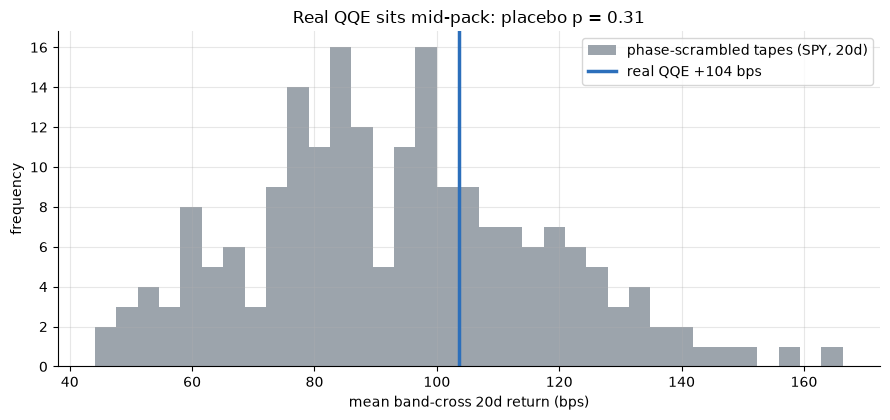

real QQE +103.6 bps   placebo p=0.31  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.phase_scramble_placebo(c, 20, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'], n_draws=200, seed=471)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng=_np.random.default_rng(471); logp=_np.log(c.to_numpy()); lr=_np.diff(logp); idx=c.index; p0=float(c.iloc[0])
    draws=[]
    for _ in range(200):
        sr=st._phase_scramble(lr,rng); sc=p0*_np.exp(_np.concatenate([[0.0],_np.cumsum(sr)]))
        import pandas as _pd; scs=_pd.Series(sc,index=idx)
        ee=st.qqe_cross_entries(scs, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
        rr=st.forward_returns(scs, ee, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(471); draws = rng.normal(95, 55, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='phase-scrambled tapes (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real QQE {obs:+.0f} bps')
ax.set_xlabel('mean band-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real QQE sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real QQE {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real QQE (blue line) sits **inside** the scrambled-timing cloud — **p = 0.31**. Nonsense-timing tapes do nearly as well, so the specific QQE band-cross isn't carrying forecasting information. This is the cleanest refutation of 'the band-cross forecasts.'

### 4d · Per-ticker — the cross does not beat random

20-day cross-minus-random delta, per instrument. If QQE worked it would be positive across the board; instead it's negative in 4 of 5.

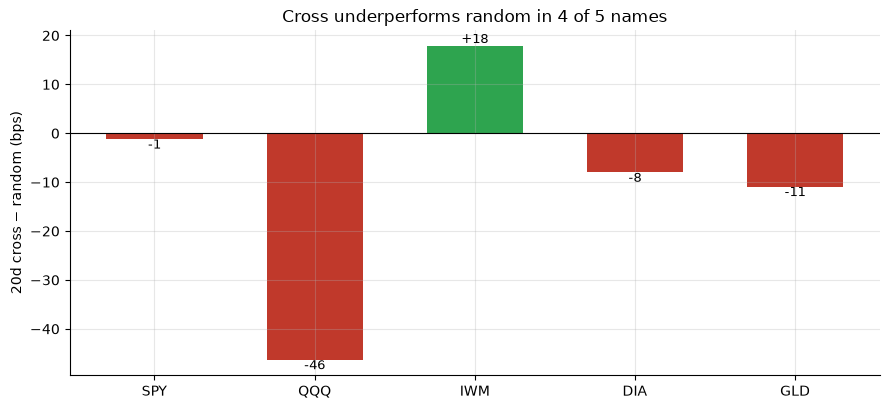

per-ticker 20d delta (bps): {'SPY': -1, 'QQQ': -46, 'IWM': 18, 'DIA': -8, 'GLD': -11}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.qqe_cross_entries(c, rsi_len=R['rsi_len'], sf=R['sf'], qqe_factor=R['qf'])
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.random_baseline(c, max(len(e),50), 20, n_seeds=40))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Cross underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **IWM** edges out a positive delta (+18 bps); QQQ is **-46** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if QQE is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-cross continuation into a synthetic tape and check the same band-cross rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

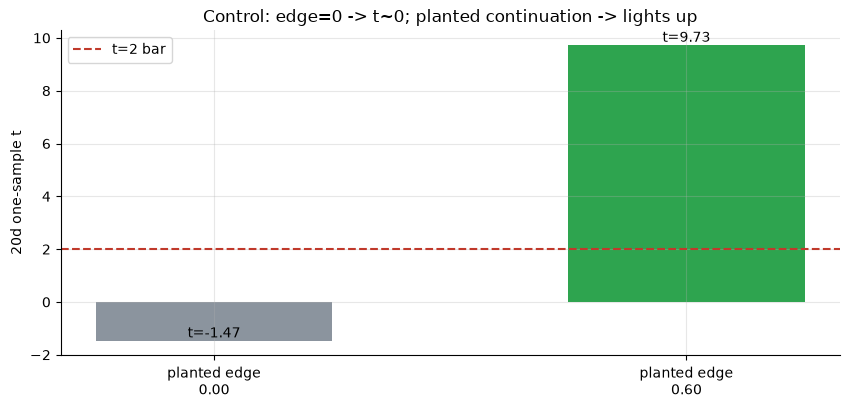

edge=0.00: n=107 cross=-64.3bps win=46% t=-1.47
edge=0.60: n=81 cross=+703.3bps win=81% t=+9.73


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=471, n_days=4000)
    c = px['close']; e = st.qqe_cross_entries(c); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = -1.47** (win 46% — no false positive); a planted continuation reaches **t = 9.73** (win 81%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the band-cross does not beat a (pooled) drift-matched random baseline (cross − random = +3/+3/-10/+6 bps at 5/10/20/60d; Welch t never clears 2, max **+0.28**). The impressive one-sample t's (20d **7.01**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Band-cross forecasts? `BUSTED`** — the phase-scramble placebo leaves the result untouched (**p = 0.31**): nonsense-timing tapes do as well as the real one, so the QQE geometry carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The band-cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The QQE rule trades *less* of the time and pays costs on each cross, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. QQE is a descriptive momentum indicator, not a forecasting strategy.

## 7 · Going further

- **The baseline-estimation lesson.** The headline finding here is methodological: the single-seed comparison *manufactures* a Welch *t* ≈ 3 'edge' for QQE that pooling annihilates. Any indicator study that benchmarks against one random draw is suspect.
- **Parameter robustness.** Sweep RSI/smoothing/factor — the drift confound is invariant.
- **QQE variants** (QQE MOD, QQE+Bollinger) are affine/cosmetic tweaks of the same smoothed-RSI-plus-band geometry and inherit the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*